# Optimierung eines Stromerzeugungsplans


Das Stromnetz versorgt nahezu jeden Bereich des modernen Lebens mit Energie - sei es das Laden eines Smartphones, der Betrieb einer Fabrik oder das Mining von Bitcoin.
Entscheidungstragende im Energiesektor muessen eine stabile und ausreichende Stromversorgung sicherstellen, die den wachsenden Energiebedarf des modernen Lebens deckt.
Schliesslich gilt: Mit grosser Leistung kommt grosse Verantwortung.

Das Management von Stromangebot und -nachfrage kann eine komplexe und anspruchsvolle Aufgabe sein. Angenommen, wir sind fuer die Stromerzeugung im US-Bundesstaat Georgia verantwortlich. Nehmen wir weiter an, dass wir alle verfuegbaren Kraftwerke sowie den stundenweisen Strombedarf eines Tages kennen. Koennen wir einen Plan erstellen, der festlegt, wie viel Strom jedes Kraftwerk erzeugen soll und wann die Anlagen ein- und ausgeschaltet werden? Wie gelingt uns das bei gleichzeitiger Minimierung der Gesamtkosten?


### Historische Stromnachfragedaten

Alle Daten finden Sie in der [Excel Datei](./excel/power-plants.xlsx).

Die Datei 'demand.csv' enthaelt die historische Stromnachfrage im Bundesstaat Georgia von 2004 bis 2013.
Diese Daten liegen fuer jede Stunde der 31 Tage von zwei Monaten vor - einem Sommermonat (Juli) und einem Wintermonat (Januar).

Fuer den weiteren Verlauf dieses Notebooks waehlen wir ein Datum, zum Beispiel den 1. Juli 2011.

Wir speichern die Nachfrage als Dictionary, das nach Stunden (zwischen 1 und 24) indiziert ist und als Werte den benoetigten Strombedarf enthaelt.

In [3]:
df_load_curves = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/demand.csv?raw=true')
# df_load_curves = pd.read_csv('demand.csv')

# Nachfrage fuer den gewaehlten Tag auswaehlen (1. Juli 2011)
df_subset = df_load_curves[(df_load_curves['YEAR']==2011)&(df_load_curves['MONTH']==7)&(df_load_curves['DAY']==1)]

# Nachfrage in einem Dictionary speichern
d = df_subset.set_index(['HOUR']).LOAD.to_dict()

H = set(d.keys()) # Menge der Stunden eines Tages (1 bis 24)

Wir koennen den Stromverbrauch in Georgia am 1. Juli 2011 visualisieren.

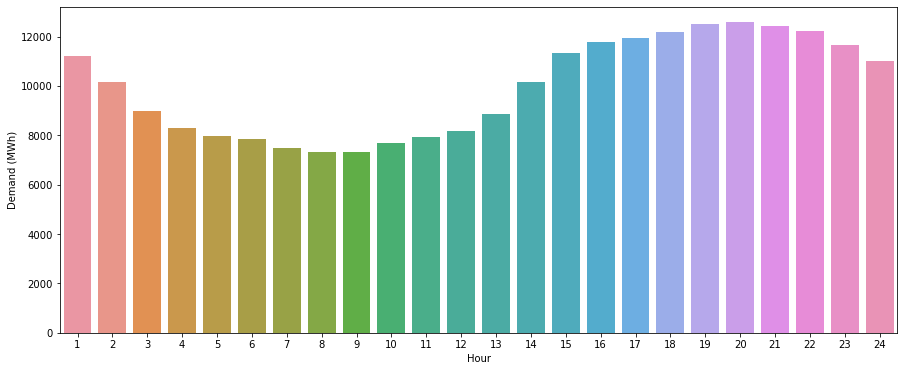

In [ ]:
fig, ax = plt.subplots(figsize=(15,6))
demand_plot = sns.barplot(x=list(range(1,25)), y=[d[h] for h in range(1,25)])
demand_plot.set_xticklabels(demand_plot.get_xticklabels());
demand_plot.set(xlabel='Stunde', ylabel='Nachfrage (MWh)');
plt.show()

Die Stromnutzung ist am Abend hoeher als am Morgen.

### Kraftwerksdaten


Die Kraftwerke unterscheiden sich nach der Art des eingesetzten Brennstoffs.
In unserem Datensatz gibt es **sechs Kraftwerkstypen**: Kohle, Kernenergie, Oel, Gas, Wasserkraft und Biomasse.
In den kleinen Daten dieses Notebooks haben wir zehn Kraftwerke - naemlich zwei Kernkraftwerke (Edwin I Hatch und Vogtle) und drei Kohlekraftwerke (Bowen, Jack McDonough und Scherer). Die uebrigen Kohlekraftwerke sind in einem Megakraftwerk mit dem Namen 'OTHER COAL' zusammengefasst. Ausserdem gibt es vier Gruppen zusammengefasster Anlagen fuer die vier Kraftwerkstypen 'BIOMASS', 'GAS', 'HYDRO' und 'OIL'.

Der von jedem Kraftwerk verwendete **Brennstoff** wird ebenfalls aus den Dateien geladen. Diese Information ist notwendig, um einige brennstoffabhaengige Kosten zu bestimmen.

In [ ]:
df_plant_info = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/plant_capacities.csv?raw=true') # "small_plant_data" durch "large_plant_data" ersetzen, um den vollstaendigen Datensatz zu verwenden
# df_plant_info = pd.read_csv('small_plant_data/plant_capacities.csv')

P = set(df_plant_info['Plant'].unique())                          # Menge aller Kraftwerke

plant_type = df_plant_info.set_index('Plant').PlantType.to_dict() # Kraftwerkstyp fuer jedes Kraftwerk

P_N = set([i for i in P if plant_type[i]=='NUCLEAR'])             # Menge aller Kernkraftwerke

fuel_type = df_plant_info.set_index('Plant').FuelType.to_dict()   # Brennstofftyp fuer jedes Kraftwerk


### Kraftwerkskapazitaeten und Grenzen

Das uebergeordnete Ziel ist es, die von jedem Kraftwerk zu erzeugende Strommenge zu bestimmen. Diese Menge muss innerhalb der minimalen und maximalen Produktionsgrenzen des jeweiligen Kraftwerks liegen (in MWh). Unten sehen Sie eine Visualisierung der maximalen Produktionsgrenzen der zehn Kraftwerke.

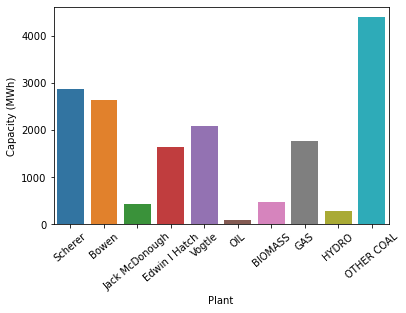

In [ ]:
df_plant_info['capacity'] = df_plant_info['Capacity']
c = df_plant_info.set_index('Plant').capacity.to_dict() # Erzeugungskapazitaet

capacity_plot = sns.barplot(x=list(c.keys()), y=[c[k] for k in c])
capacity_plot.set_xticklabels(capacity_plot.get_xticklabels(), rotation=40);
capacity_plot.set(xlabel='Kraftwerk', ylabel='Kapazitaet (MWh)');
plt.show()

Offensichtlich koennen Kohlekraftwerke die hoechsten Produktionskapazitaeten bereitstellen, gefolgt von Kernkraft- und Wasserkraftwerken.

Wenn ein Kernkraftwerk eingeschaltet ist, muss es zudem mindestens 80% seiner maximalen Kapazitaet erzeugen. Fuer die uebrigen Kraftwerke setzen wir diese Untergrenze auf 1%.

Zusaetzlich gibt es eine Grenze dafuer, wie stark der Erzeugungsplan die Stromproduktion zwischen aufeinanderfolgenden Stunden **hochfahren** oder **herunterfahren** darf.
Diese Grenze stellt sicher, dass die Kraftwerke nicht zu drastischen Aenderungen ihres Fahrplans gezwungen werden.

Wir setzen diese Geschwindigkeitsgrenze auf **20%** fuer Kernkraftwerke und **25%** fuer Kohlekraftwerke. Mit anderen Worten: Ein Kohlekraftwerk darf innerhalb einer Stunde nicht um mehr als 25% seiner Gesamtkapazitaet hoch- oder heruntergefahren werden.
Fuer alle anderen Kraftwerke setzen wir die Grenze auf **100%** und legen damit keine wirksame Begrenzung der Geschwindigkeit fest.

### Kosten

Abschliessend laden wir die Kostendaten. Es gibt fuenf Kostenarten: Brennstoffkosten, Betriebskosten, Anfahr- und Abschaltkosten sowie Gesundheitskosten.
Fuer diese Kosten liegen historische jaehrliche Durchschnittsdaten (2004-2011) nach Brennstofftyp vor.
Im weiteren Verlauf des Notebooks verwenden wir die Durchschnittskosten fuer 2011.

Zunaechst betrachten wir die **Brennstoffkosten**, also die Kosten zur Erzeugung von *einer* MWh Strom.
Wie unten visualisiert, sind die Brennstofftypen Kohle und Gas am teuersten, waehrend Kernenergie am guenstigsten ist.

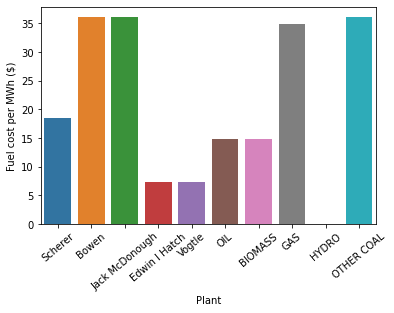

In [ ]:
df_fuel_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/fuel_costs.csv?raw=true')
# df_fuel_costs = pd.read_csv('small_plant_data/fuel_costs.csv')

# Brennstoffkosten einlesen und von Brennstofftyp auf Kraftwerksnamen abbilden
f = {i: df_fuel_costs[df_fuel_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # Dictionary der Brennstoffkosten je Kraftwerk

# Brennstoffkosten plotten
fuelcost_plot = sns.barplot(x=list(f.keys()), y=[f[k] for k in f])
fuelcost_plot.set_xticklabels(fuelcost_plot.get_xticklabels(), rotation=40);
fuelcost_plot.set(xlabel='Kraftwerk', ylabel='Brennstoffkosten pro MWh ($)');
plt.show()

Die zweite Kostenart sind die **Betriebskosten**, also die Kosten pro Stunde fuer den Betrieb eines eingeschalteten Kraftwerks.

In [ ]:
df_oper_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/operating_costs.csv?raw=true')
# df_oper_costs = pd.read_csv('small_plant_data/operating_costs.csv')
o = {i: df_oper_costs[df_oper_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # Betriebskosten/MWh (Kraftwerk)

Die dritte und vierte Kostenart sind die **Anfahr-** und **Abschaltkosten**, die jedes Hoch- und Herunterfahren eines Kraftwerks bestrafen. Die Beruecksichtigung dieser Kosten im Modell sorgt fuer einen stabileren Stromerzeugungsplan.

In [ ]:
df_startup_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/startup_costs.csv?raw=true')
# df_startup_costs = pd.read_csv('small_plant_data/startup_costs.csv')
s = {i: df_startup_costs[df_startup_costs['year']==2011].T.to_dict()[9][fuel_type[i]] for i in fuel_type} # Anfahrkosten/MWh (Kraftwerk)

t = s.copy() # Annahme: Kosten fuer das Abschalten = Kosten fuer das Anfahren

Zum Schluss laden wir die **Gesundheitskosten**, die die gesundheitlichen Auswirkungen eines zu hohen Kohleverbrauchs erfassen. Diese Daten liegen nur fuer die drei Kohlekraftwerke (Bowen, Jack McDonough und Scherer) vor.


Die Gesundheitskosten werden anhand verschiedener Umweltfaktoren aggregiert, die von der Tageszeit abhaengen. Deshalb sind diese Kosten fuer jede Stunde indiziert. In der folgenden Visualisierung der Gesundheitskosten fuer das Kraftwerk Bowen sieht man, dass die Kosten am Abend deutlich hoeher sind als am Morgen.

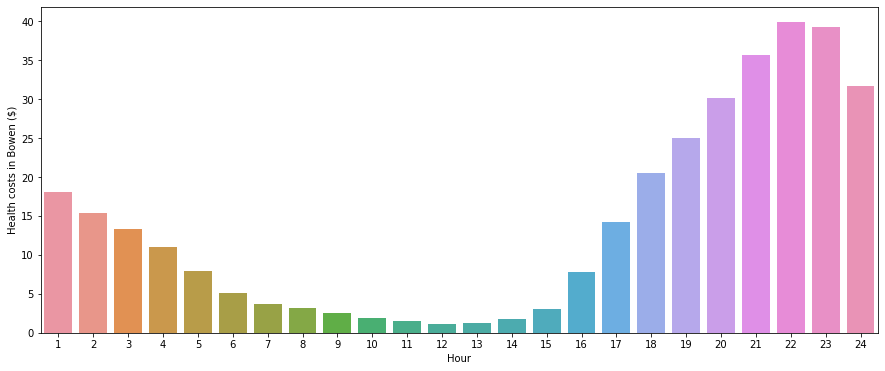

In [ ]:
df_health_costs = pd.read_csv('https://github.com/Gurobi/modeling-examples/blob/master/power_generation/small_plant_data/health_costs.csv?raw=true')
# df_health_costs = pd.read_csv('small_plant_data/health_costs.csv')
a = df_health_costs[(df_health_costs['Year']==2007)&(df_health_costs['Day']==1)].set_index(['Plant','Hour']).to_dict()['Cost'] # Gesundheitskosten/MWh (Kraftwerk)
a.update({(i,h): 0 for i in P for h in H if i not in ['Bowen','Jack McDonough','Scherer']})

fig, ax = plt.subplots(figsize=(15,6))
healthcost_plot = sns.barplot(x=list(range(1,25)), y=[a['Bowen',h] for h in range(1,25)])
healthcost_plot.set_xticklabels(healthcost_plot.get_xticklabels());
healthcost_plot.set(xlabel='Stunde', ylabel='Gesundheitskosten in Bowen ($)');
plt.show()